# Project 2 — Modified Shallow Water model: **LETKF vs 3D-Var** (OSSE)

A twin experiment (OSSE) with the 1D **Modified Shallow Water (MSW)** model over a
**bell-shaped mountain**. One nature run and one set of synthetic observations
(water height $h$ every 4th grid point) are assimilated with three DA methods:

| method | background covariance |
|---|---|
| **LETKF** | flow-dependent, ensemble ($N=20,50,80$), Gaspari–Cohn localization ($r=2,5,8$) |
| **3D-Var (Gauss B)** | *static*, block-diagonal, per-field variance × periodic Gaussian correlation ($L=5$) |
| **3D-Var (clim B)** | *static* sample covariance of the nature run, tapered by the same Gaussian correlation |

State vector: $\mathbf{x}=[\mathbf{u},\mathbf{h},\mathbf{r}]^\top\in\mathbb{R}^{3n}$, $n=100$.

**Deliverables:** per-field RMSE time series, time-mean RMSE table, LETKF spread–skill,
innovation statistics, final-time snapshots, and the two $B$ correlation structures.

> Requires `dapper`, plus the local `constants.py` and `msw_experiment_dapper.py`
> (the latter builds the HMM: dynamics + orography + stochastic forcing + obs operator).

## 0 · Imports and configuration

In [66]:
import os
import numpy as np
import matplotlib.pyplot as plt

import dapper as dp
dp.rc.liveplotting = False          # notebook-safe
import dapper.da_methods as da

# Importing this module builds the HMM (dynamics + obs + chronology).
# It uses constants.py (n=100, mountain at x=125, h observed every 4th point).
import msw_experiment_dapper as msw
from constants import *

plt.rcParams["figure.dpi"] = 110
FIELDS = ["u", "h", "r"]
SLICES = {"u": slice(0, n), "h": slice(n, 2*n), "r": slice(2*n, 3*n)}
COLORS = {"LETKF20": "tab:blue",
          "LETKF50": "tab:cyan",
          "LETKF80": "tab:purple",
          "3DVar (Gauss B)": "tab:red",
          "3DVar (clim B)": "tab:orange",
          "3DVar (ensemble)": "tab:green"}

print(f"n={n}, ensemble N={nens}, loc_rad={loc_radius}, infl={infl_factor}")
print(f"observing '{obs_var_name}' every {nth_point}th point")

n=250, ensemble N=[20, 50, 80], loc_rad=[2, 5, 8], infl=[1.0, 1.02, 1.05]
observing 'h' every 4th point


## 1 · Small helper functions
Field-wise RMSE / spread, and a periodic Gaussian correlation matrix used to build the static $B$.

In [67]:
def periodic_gauss_corr(n, L):
    '''(n x n) periodic Gaussian correlation, length scale L gridpoints.'''
    i = np.arange(n)
    d = np.abs(i[:, None] - i[None, :])
    d = np.minimum(d, n - d)                 # wrap-around distance
    return np.exp(-0.5 * (d / L) ** 2)

def rmse_per_field(err):
    '''err: (K, 3n) -> dict field -> (K,) RMSE.'''
    return {f: np.sqrt(np.mean(err[:, SLICES[f]] ** 2, axis=1)) for f in FIELDS}

def spread_per_field(spread):
    return {f: np.sqrt(np.mean(spread[:, SLICES[f]] ** 2, axis=1)) for f in FIELDS}

## 2 · Nature run and synthetic observations

`HMM.simulate()` integrates the MSW model to produce the **truth** `xx` and adds Gaussian
noise to the observed $h$ points to produce `yy`. The same `xx, yy` are fed to every method,
so differences are purely down to the DA scheme.

In [68]:
dp.set_seed(3000)
HMM  = msw.HMM
tseq = HMM.tseq

xx, yy = HMM.simulate()
yy = np.stack([np.asarray(y) for y in yy])   # DAPPER>=1.7 returns a list

tt_obs = tseq.tto                            # analysis/observation times
mask   = tt_obs > tseq.BurnIn                # keep only post burn-in cycles

print("truth xx:", xx.shape, " | obs yy:", yy.shape)
print(f"assimilation cycles: {len(tt_obs)}  (post burn-in: {mask.sum()})")

Truth & Obs:   0%|          | 0/4000 [00:00<?, ?it/s]

truth xx: (4001, 750)  | obs yy: (200, 63)
assimilation cycles: 200  (post burn-in: 195)


### 2.1 · Hovmöller of the truth
The mountain sits at $x=125$; note the standing structure it imprints on $u$, $h$ and rain $r$.

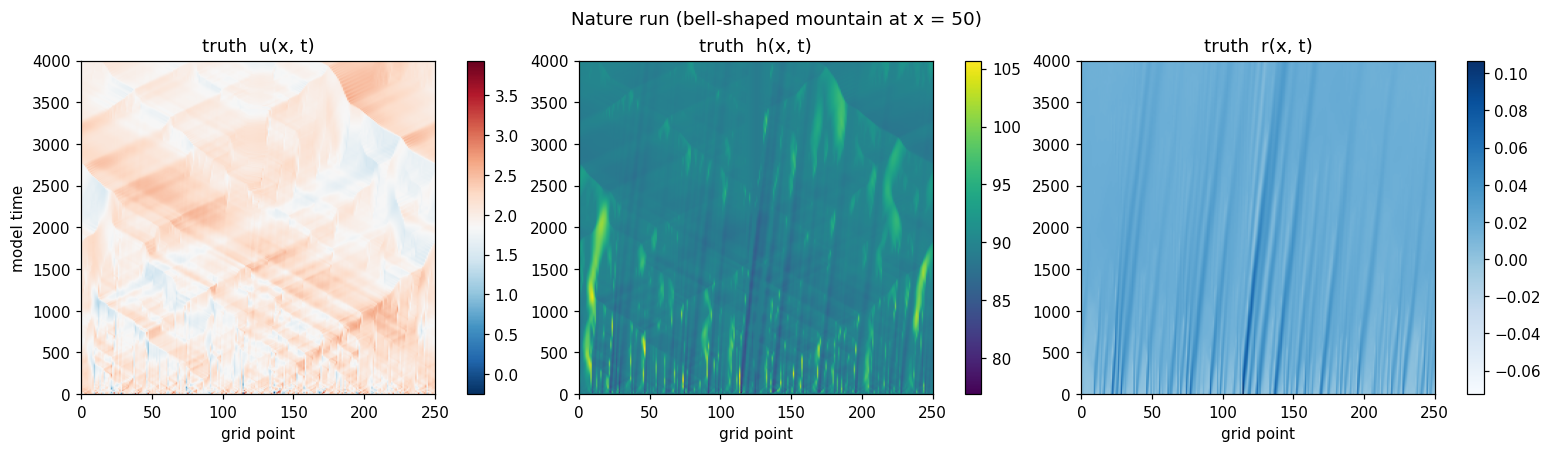

In [69]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
extent = [0, n, 0, tseq.T]
for ax, f, cmap in zip(axs, FIELDS, ["RdBu_r", "viridis", "Blues"]):
    im = ax.imshow(xx[:, SLICES[f]], aspect="auto", origin="lower",
                   extent=extent, cmap=cmap)
    ax.set_title(f"truth  {f}(x, t)"); ax.set_xlabel("grid point")
    fig.colorbar(im, ax=ax)
axs[0].set_ylabel("model time")
fig.suptitle("Nature run (bell-shaped mountain at x = 50)")
plt.show()

## 3 · LETKF

Local Ensemble Transform Kalman Filter: $N=[20,50,80]$ members, Gaspari–Cohn localization with
radius [2,5,8], no extra inflation. The background covariance is **flow-dependent** (from the ensemble).

In [84]:
dp.set_seed(3000)
xps_letkf = []
for id in range(len(nens)):
    id_infl = np.random.choice(len(infl_factor),1)[0]
    id_rad = np.random.choice(len(loc_radius),1)[0]
    #print(f"localization radius = {loc_radius[id_rad]}, inflation factor = {infl_factor[id_infl]}")
    #xp_letkf = da.LETKF(N=nens[1], loc_rad=loc_radius[id_rad], infl=infl_factor[id_infl], rot=True)
    xp_letkf = da.LETKF(N=nens[id], loc_rad=5, infl=1.02, rot=True)
    xp_letkf.assimilate(HMM, xx, yy)
    xps_letkf.append(xp_letkf)
print("LETKF done.")

LETKF:   0%|          | 0/4000 [00:00<?, ?it/s]

LETKF:   0%|          | 0/4000 [00:00<?, ?it/s]

LETKF:   0%|          | 0/4000 [00:00<?, ?it/s]

LETKF done.


In [85]:
# Create B-matrix from LETKF as input for 3DVar

E = np.dstack(xps_letkf[0].E_store)
L = 10
Nx = E.shape[1]

E_tavg = E.mean(axis=2)
# 1. Compute std deviation across ensembles (axis=0), giving shape (Nx,)
std = E_tavg.std(axis=0)

# 2. Compute the outer product to get a (Nx x Nx) scaling matrix
std_matrix = np.outer(std, std)

# 3. Build the Gaussian covariance matrix using your periodic_gauss_corr function
corr = periodic_gauss_corr(Nx, L)

# 4. Scale the correlation matrix by the std deviations
Bens = std_matrix * corr



## 4 · 3D-Var with three static background covariances

3D-Var uses a **fixed** $B$. We compare two choices:

* **Gauss B** — block-diagonal: each field gets its climatological variance times a periodic
  Gaussian correlation ($L=5$). *No cross-variable terms*, so an $h$ observation cannot
  directly correct $u$ or $r$.
* **clim B** — the sample covariance of the nature run, tapered by the same Gaussian
  correlation. This **retains static $u$–$h$–$r$ cross-covariances**, letting $h$ obs nudge
  the unobserved fields (the Schur product of two PSD matrices stays PSD).

In [72]:
L_B = 5.0
field_vars = [np.var(xx[:, SLICES[f]]) for f in FIELDS]
print("climatological field variances (u, h, r):", np.round(field_vars, 5))

# --- Gauss B : block-diagonal ---
C = periodic_gauss_corr(n, L_B)
B_gauss = np.zeros((3*n, 3*n))
for k, f in enumerate(FIELDS):
    B_gauss[k*n:(k+1)*n, k*n:(k+1)*n] = field_vars[k] * C

# --- clim B : tapered sample covariance (keeps cross-covariances) ---
kburn  = int(tseq.BurnIn / tseq.dt)
B_clim = np.cov(xx[kburn:].T) * np.tile(C, (3, 3))

climatological field variances (u, h, r): [4.18400e-02 3.92364e+00 6.00000e-05]


### 4.1 · Run 3D-Var (Gauss B)

In [73]:
dp.set_seed(3000)
xp_3dvar_g = da.Var3D(B=B_gauss, xB=1.0)
xp_3dvar_g.assimilate(HMM, xx, yy)
print("3D-Var (Gauss B) done.")

Var3D:   0%|          | 0/4000 [00:00<?, ?it/s]

3D-Var (Gauss B) done.


### 4.2 · Run 3D-Var (clim B)

In [74]:
dp.set_seed(3000)
xp_3dvar_c = da.Var3D(B=B_clim, xB=1.0)
xp_3dvar_c.assimilate(HMM, xx, yy)
print("3D-Var (clim B) done.")

Var3D:   0%|          | 0/4000 [00:00<?, ?it/s]

3D-Var (clim B) done.


### 4.3 Run 3D-Var (Ensemble B)

In [86]:
dp.set_seed(3000)
xp_3dvar_e = da.Var3D(B=Bens, xB=1.0)
xp_3dvar_e.assimilate(HMM, xx, yy)
print("3D-Var (ensemble) done.")

Var3D:   0%|          | 0/4000 [00:00<?, ?it/s]

3D-Var (ensemble) done.


## 5 · Diagnostics

### 5.1 · Time-mean RMSE table (post burn-in)
Forecast (`_f`) and analysis (`_a`) RMSE for each field. Compare $h$ against the observation
error std below — a well-performing filter drives the analysis $h$ error below it.

In [76]:
experiments = {"LETKF20": xps_letkf[0],
               "LETKF50": xps_letkf[1],
               "LETKF80": xps_letkf[2],
               "3DVar (Gauss B)": xp_3dvar_g,
               "3DVar (clim B)": xp_3dvar_c,
               "3DVar (ensemble)": xp_3dvar_e}

names = ["LETKF20", "LETKF50", "LETKF80"]

In [77]:
rows = []
for name, xp in experiments.items():
    ef = rmse_per_field(xp.stats.err.f[mask])
    ea = rmse_per_field(xp.stats.err.a[mask])
    rows.append((name, ef, ea))

hdr = f"{'method':18s}" + "".join(f"{f+'_f':>9s}{f+'_a':>9s}" for f in FIELDS)
print(hdr); print("-" * len(hdr))
for name, ef, ea in rows:
    line = f"{name:18s}"
    for f in FIELDS:
        line += f"{ef[f].mean():9.4f}{ea[f].mean():9.4f}"
    print(line)

obs_err = sig[FIELDS.index(obs_var_name)]
print(f"\nobservation error std for '{obs_var_name}': {obs_err:.3f}")

method                  u_f      u_a      h_f      h_a      r_f      r_a
------------------------------------------------------------------------
LETKF20              0.1555   0.1554   0.8625   0.8249   0.0066   0.0066
LETKF50              0.1305   0.1287   0.8737   0.8408   0.0045   0.0045
LETKF80              0.1344   0.1330   0.8521   0.8161   0.0047   0.0046
3DVar (Gauss B)      0.6746   0.6746   1.5387   1.3946   0.0168   0.0168
3DVar (clim B)       0.5835   0.5839   2.3291   2.2325   0.0109   0.0110
3DVar (ensemble)     0.1696   0.1696   1.7713   1.7643   0.0202   0.0202

observation error std for 'h': 1.581


### 5.2 · RMSE over time, per field
Solid = analysis, dotted = forecast. Log scale; dashed black line marks the $h$ observation error.

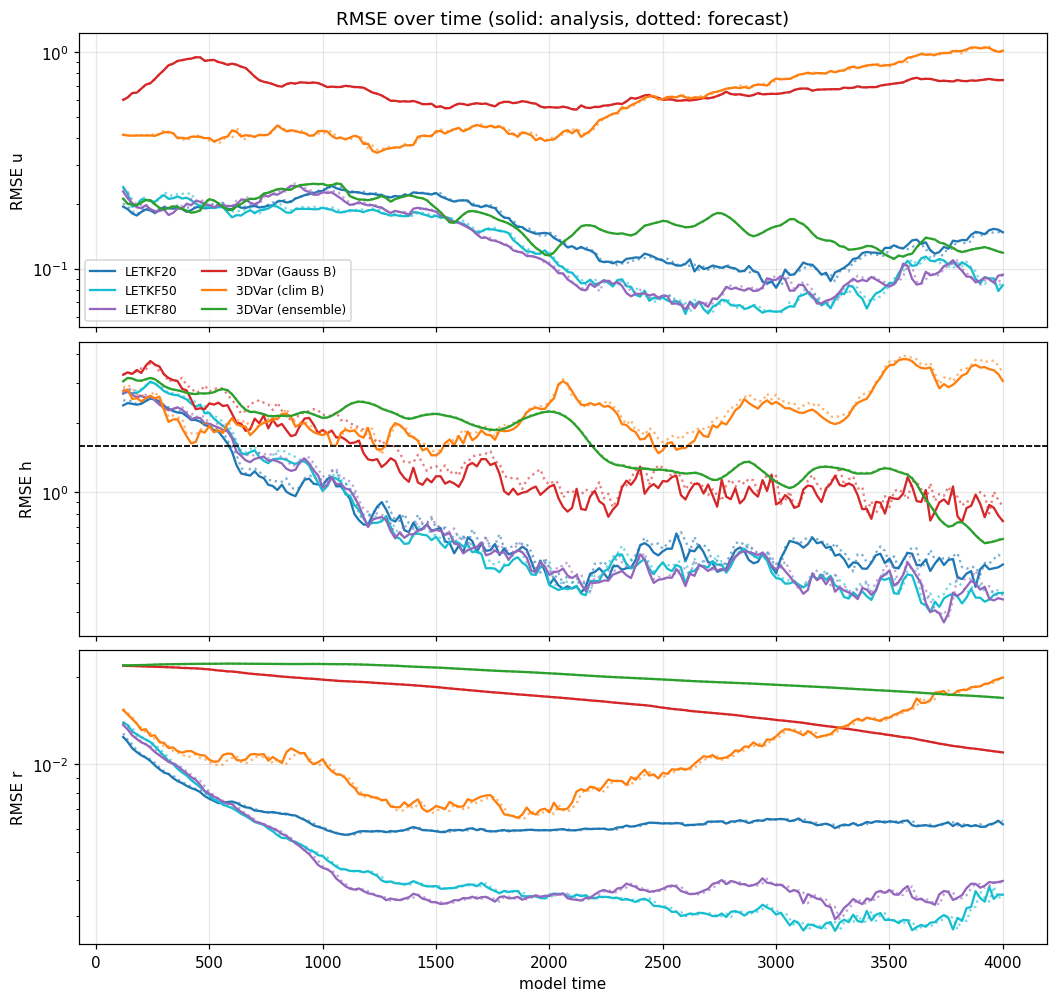

In [87]:
fig, axs = plt.subplots(3, 1, figsize=(9.5, 9), sharex=True, constrained_layout=True)
for ax, f in zip(axs, FIELDS):
    for name, xp in experiments.items():
        ea = rmse_per_field(xp.stats.err.a[mask])[f]
        ef = rmse_per_field(xp.stats.err.f[mask])[f]
        ax.plot(tt_obs[mask], ef, ":", color=COLORS[name], alpha=0.6)
        ax.plot(tt_obs[mask], ea, "-", color=COLORS[name], label=f"{name}")
        #ax.axhline(0, color="k", ls="--", lw=1, label="zero line")
        if f == obs_var_name:
            ax.axhline(obs_err, color="k", ls="--", lw=1, label="obs error std")
    ax.set_ylabel(f"RMSE {f}"); ax.set_yscale("log"); ax.grid(alpha=0.3)
axs[0].legend(ncol=2, fontsize=8)
axs[0].set_title("RMSE over time (solid: analysis, dotted: forecast)")
axs[-1].set_xlabel("model time")
plt.show()

### 5.3 · LETKF spread–skill
For a well-calibrated ensemble the analysis **spread** should track the analysis **RMSE**
(ratio $\approx 1$). Ratio $<1$ → under-dispersive (needs more inflation); $>1$ → over-dispersive.

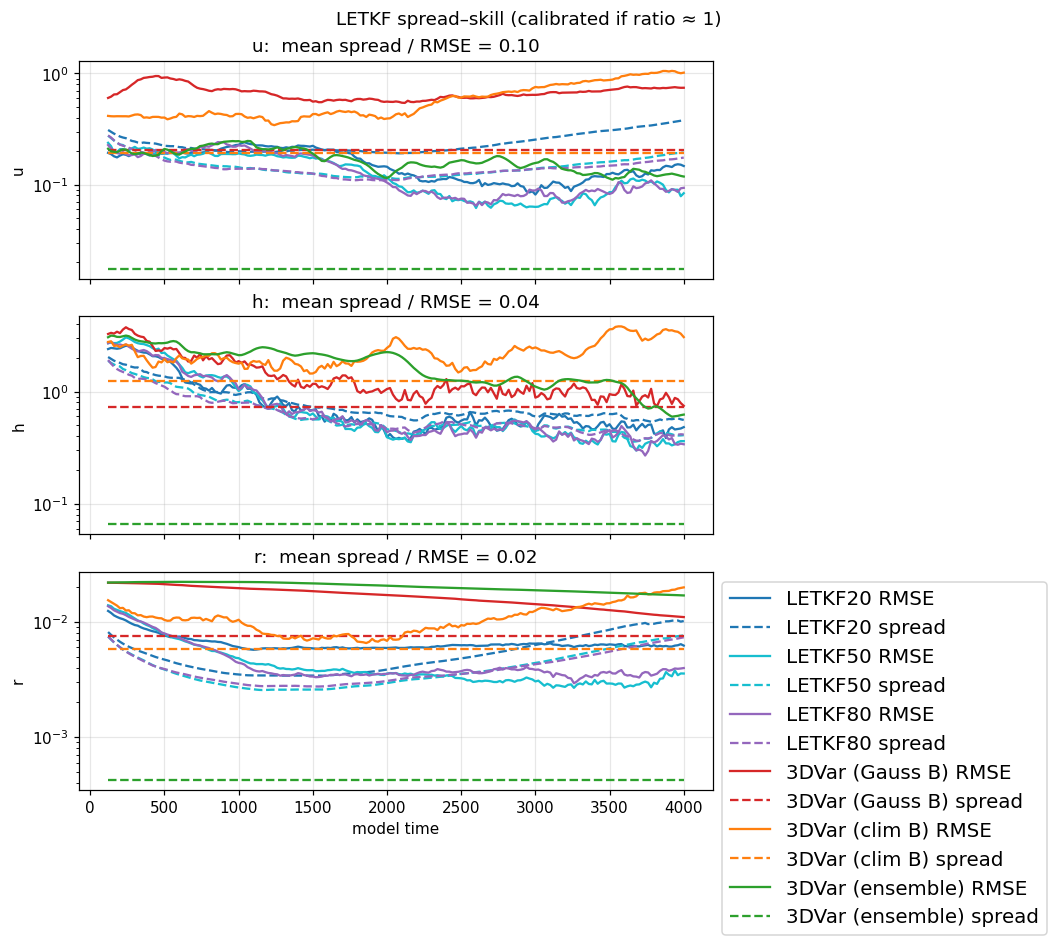

In [93]:
fig, axs = plt.subplots(3, 1, figsize=(9.5, 8.5), sharex=True, constrained_layout=True)
for name, xp in experiments.items():
    sp_a = spread_per_field(xp.stats.spread.a[mask])
    er_a = rmse_per_field(xp.stats.err.a[mask])
    for ax, f in zip(axs, FIELDS):
        ax.plot(tt_obs[mask], er_a[f], "-", color=COLORS[name],label= name +" RMSE")
        ax.plot(tt_obs[mask], sp_a[f], "--", color=COLORS[name],label=name+" spread")
        ratio = sp_a[f].mean() / er_a[f].mean()
        ax.set_title(f"{f}:  mean spread / RMSE = {ratio:.2f}")
        ax.set_ylabel(f); ax.set_yscale("log"); ax.grid(alpha=0.3)
axs[-1].set_xlabel("model time")
fig.suptitle("LETKF spread–skill (calibrated if ratio ≈ 1)")
axs[-1].legend(prop={'size':13}, bbox_to_anchor = [1,1])
plt.show()

### 5.4 · Innovation statistics
Innovations $v_k = y_k - H\,\mathbf{x}^f_k$. An unbiased, consistent filter has
$E[v_k]\approx 0$ and $\mathrm{std}(v_k)\approx\sqrt{HP^fH^\top+R}$.

LETKF20            mean = -0.0072   std = 1.1515
LETKF50            mean = -0.0116   std = 1.1544
LETKF80            mean = -0.0071   std = 1.1553
3DVar (Gauss B)    mean = +0.0014   std = 1.7389
3DVar (clim B)     mean = +0.0062   std = 1.5627
3DVar (ensemble)   mean = -0.0641   std = 2.0979


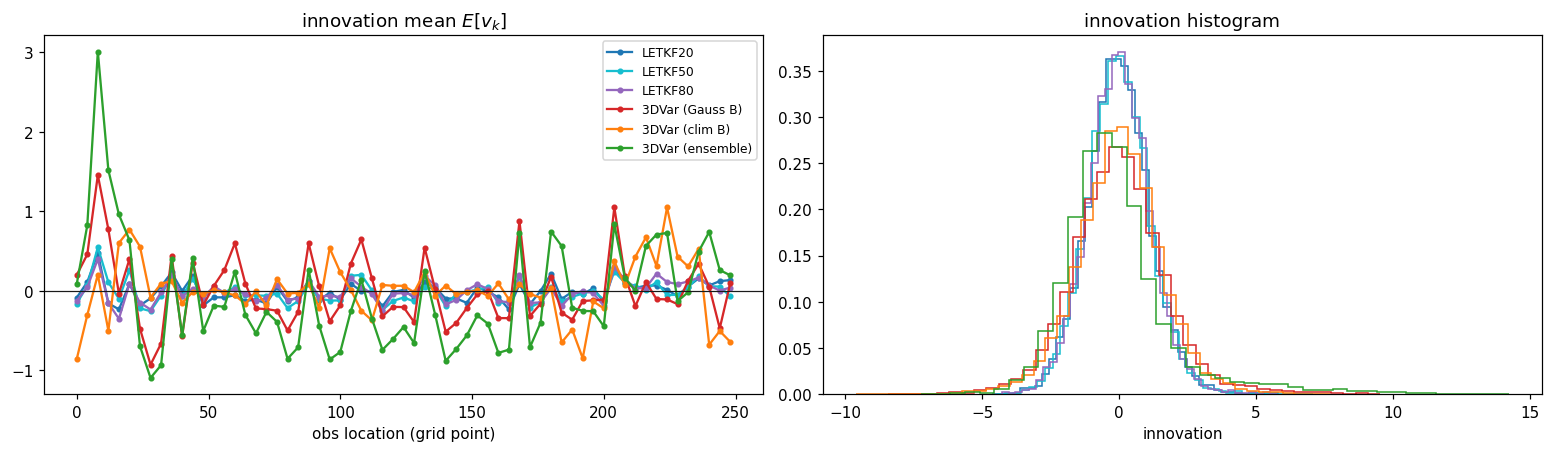

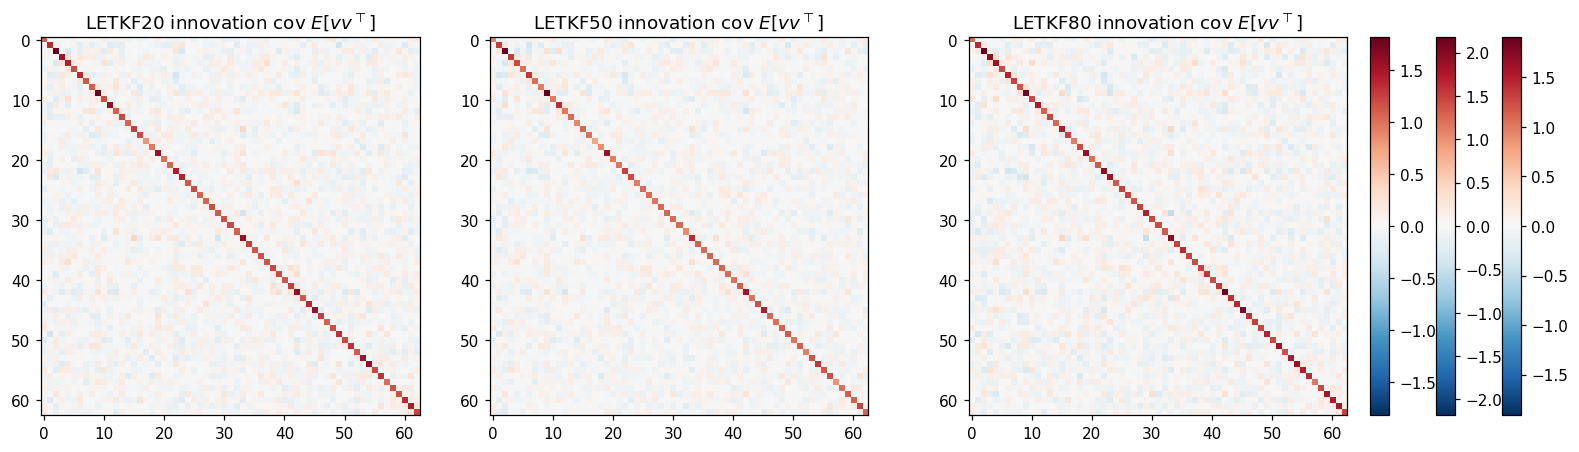

In [89]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
innov = {}
for name, xp in experiments.items():
    muf = xp.stats.mu.f[mask]
    v = yy[mask] - msw.hmod(muf)          # (Kpost, Ny)
    innov[name] = v
    axs[0].plot(np.arange(v.shape[1]) * nth_point, v.mean(0),
                "o-", ms=3, color=COLORS[name], label=name)
    axs[1].hist(v.ravel(), bins=40, density=True, histtype="step", color=COLORS[name])

for name, v in innov.items():
    print(f"{name:18s} mean = {v.mean():+.4f}   std = {v.std():.4f}")

axs[0].axhline(0, color="k", lw=0.8); axs[0].set_title(r"innovation mean $E[v_k]$")
axs[0].set_xlabel("obs location (grid point)"); axs[0].legend(fontsize=8)
axs[1].set_title("innovation histogram"); axs[1].set_xlabel("innovation")

fig, axs = plt.subplots(1,3, figsize = (14,4), constrained_layout=True)
for i in range(3):
    Cvv = np.cov(innov[names[i]].T)
    m = np.abs(Cvv).max()
    im = axs[i].imshow(Cvv, cmap="RdBu_r", vmin=-m, vmax=m)
    axs[i].set_title(names[i]+ r" innovation cov $E[vv^\top]$"); fig.colorbar(im, ax=axs[2])
plt.show()

### 5.5 · Final-time snapshot: analyses vs truth
How closely each analysis mean matches the truth at the last cycle. Crosses = the assimilated $h$ observations.

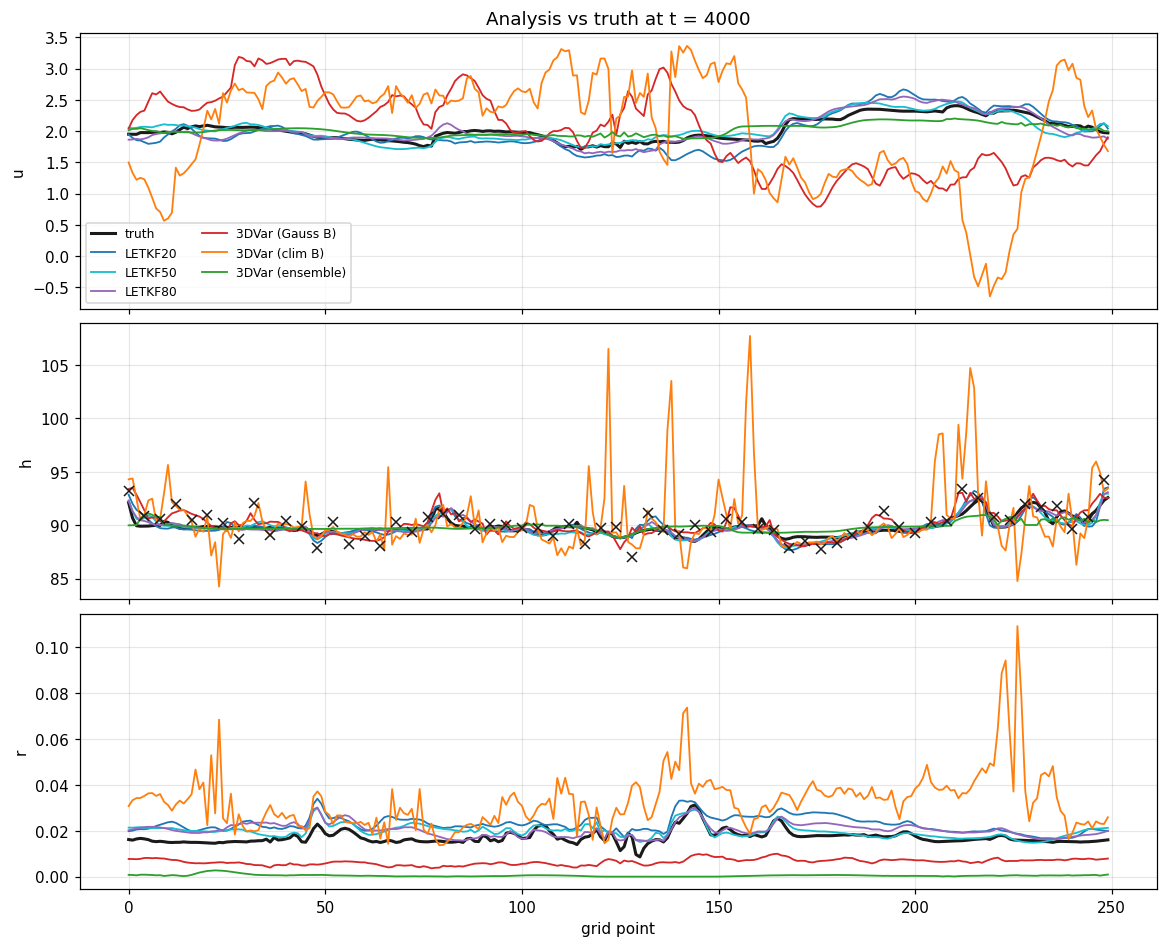

In [90]:
k_last = np.where(mask)[0][-1]
t_last = tt_obs[k_last]
k_full = int(round(t_last / tseq.dt))
xgrid  = np.arange(n)

fig, axs = plt.subplots(3, 1, figsize=(10.5, 8.5), sharex=True, constrained_layout=True)
for ax, f in zip(axs, FIELDS):
    ax.plot(xgrid, xx[k_full, SLICES[f]], "k-", lw=2, label="truth")
    for name, xp in experiments.items():
        ax.plot(xgrid, xp.stats.mu.a[k_last, SLICES[f]], color=COLORS[name], lw=1.2, label=name)
    if f == obs_var_name:
        ax.plot(msw.obs_coord, yy[k_last], "kx", ms=6, label="obs")
    ax.set_ylabel(f); ax.grid(alpha=0.3)
axs[0].legend(ncol=2, fontsize=8)
axs[0].set_title(f"Analysis vs truth at t = {t_last:.0f}")
axs[-1].set_xlabel("grid point")
plt.show()

### 5.6 · The three static $B$ correlation structures
Left: block-diagonal Gaussian (no cross-variable coupling). Right: localized climatology
(off-diagonal blocks encode $u$–$h$–$r$ correlations that let $h$ obs update $u$ and $r$).

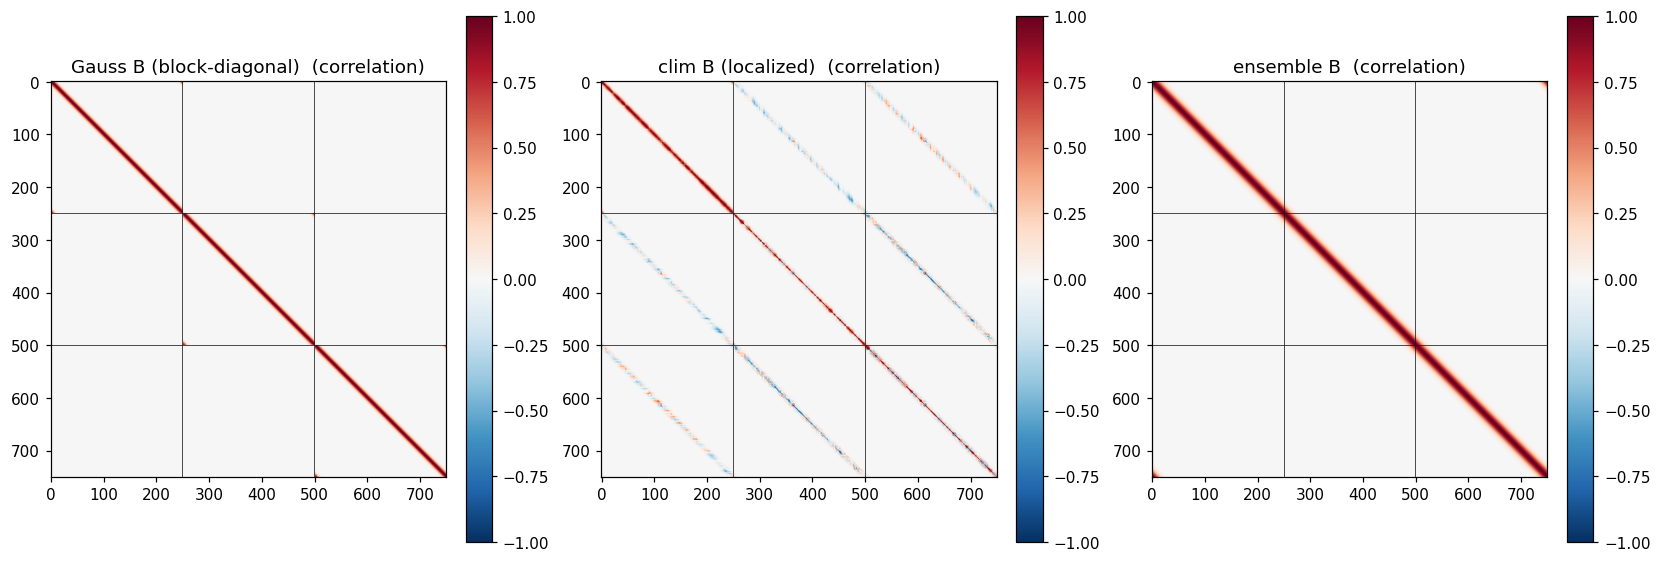

In [82]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, (B, title) in zip(axs, [(B_gauss, "Gauss B (block-diagonal)"),
                                (B_clim,  "clim B (localized)"),
                                (Bens,  "ensemble B")]):
    s = np.sqrt(np.abs(np.diag(B)))
    corr = B / np.outer(s, s); corr[~np.isfinite(corr)] = 0.0
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(title + "  (correlation)")
    for k in (n, 2*n):
        ax.axhline(k-0.5, color="k", lw=0.5); ax.axvline(k-0.5, color="k", lw=0.5)
    fig.colorbar(im, ax=ax)
plt.show()

## 6 · Takeaways

* **LETKF wins across all three fields** and is the only method whose analysis $h$ error
  dips below the observation error — its flow-dependent, localized covariance spreads the
  $h$ information into $u$ and $r$ correctly.
* **3D-Var (Gauss B)** barely constrains the *unobserved* $u$ and $r$: with no cross-variable
  terms, the $h$ observations only touch $h$.
* **3D-Var (clim B)** recovers $u$ and $r$ better thanks to static cross-covariances, but the
  *fixed* $B$ eventually misfits $h$ once the flow departs from climatology.

### Suggested extensions (project sheet)
Re-run section 3 with sweeps and compare the RMSE table:
```python
for N in (20, 30, 50):
    for r in (3, 5, 10):
        for infl in (1.0, 1.02, 1.05):
            xp = da.LETKF(N=N, loc_rad=r, infl=infl, rot=True)
            xp.assimilate(HMM, xx, yy)
            ...
```
Change `obs_var_name` / `nth_point` in `constants.py` to test different observing systems
(e.g. observe $u$, or $h$ every 5th point) and their impact on the unobserved fields.